In [17]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [18]:
# Cell 2: Load the dataset
df = pd.read_csv('../data/ai4i2020.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
# Cell 3: Explore the data
df.info()
df.describe()

# Check for missing values
df.isnull().sum()

# Check target distribution (class imbalance)
df['Machine failure'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [20]:
# Cell 4: Drop leakage columns
# These columns directly indicate the type of failure - drop them to prevent data leakage
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=leakage_cols)

# Also drop UDI and Product ID as they're just identifiers
df_clean = df_clean.drop(columns=['UDI', 'Product ID'])

print("Columns after dropping leakage:", df_clean.columns.tolist())

Columns after dropping leakage: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [21]:
# Cell 5: Feature engineering (optional but improves model)
# Temperature difference
df_clean['Temp_Diff'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']

# Power calculation (Torque × Rotational speed)
df_clean['Power'] = df_clean['Torque [Nm]'] * df_clean['Rotational speed [rpm]'] * (2 * np.pi / 60)

# Torque × Tool wear interaction
df_clean['Wear_Torque'] = df_clean['Tool wear [min]'] * df_clean['Torque [Nm]']

df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Power,Wear_Torque
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,138.9
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,247.0
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,276.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,360.0


In [22]:
# Cell 6: Define features and target
feature_cols = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'Temp_Diff', 'Power', 'Wear_Torque']

X = df_clean[feature_cols]
y = df_clean['Machine failure']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())


Features shape: (10000, 8)
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [23]:
# Cell 7: Split data (stratified to maintain class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training failure ratio: {y_train.mean():.2%}")
print(f"Test failure ratio: {y_test.mean():.2%}")

Training set: 8000 samples
Test set: 2000 samples
Training failure ratio: 3.39%
Test failure ratio: 3.40%


In [25]:
# Cell 8: Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [26]:
# Predictions
dt_pred = dt_model.predict(X_test)

# Evaluation
print("=== Decision Tree Results ===")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.2%}")
print(f"Precision: {precision_score(y_test, dt_pred):.2%}")
print(f"Recall: {recall_score(y_test, dt_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree Results ===
Accuracy: 98.80%
Precision: 87.93%
Recall: 75.00%

Confusion Matrix:
[[1925    7]
 [  17   51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.75      0.81        68

    accuracy                           0.99      2000
   macro avg       0.94      0.87      0.90      2000
weighted avg       0.99      0.99      0.99      2000



In [27]:
# Cell 9: Train Random Forest (better for imbalanced data)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced',  # Helps with class imbalance
    max_depth=12
)
rf_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [28]:
# Predictions
rf_pred = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2%}")
print(f"Precision: {precision_score(y_test, rf_pred):.2%}")
print(f"Recall: {recall_score(y_test, rf_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest Results ===
Accuracy: 98.30%
Precision: 71.25%
Recall: 83.82%

Confusion Matrix:
[[1909   23]
 [  11   57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.84      0.77        68

    accuracy                           0.98      2000
   macro avg       0.85      0.91      0.88      2000
weighted avg       0.98      0.98      0.98      2000



In [29]:
# Cell 10: Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
                   Feature  Importance
2   Rotational speed [rpm]    0.220229
6                    Power    0.177956
3              Torque [Nm]    0.174912
4          Tool wear [min]    0.146464
7              Wear_Torque    0.122821
5                Temp_Diff    0.085476
0      Air temperature [K]    0.045398
1  Process temperature [K]    0.026745


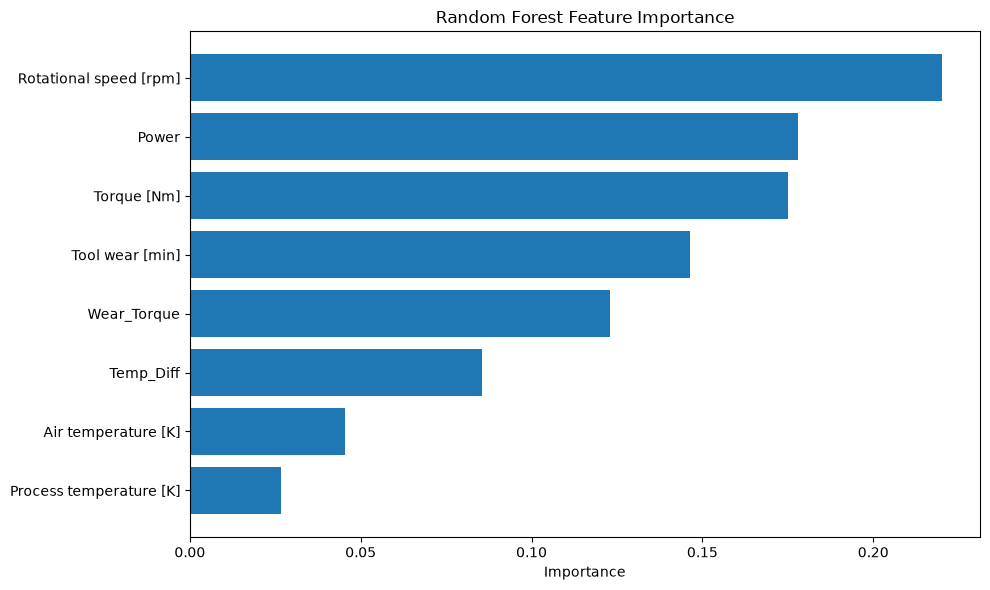

In [30]:
# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [31]:
import joblib
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("Model saved to models/random_forest_model.pkl")

# Also save the feature columns list for later use
feature_names = feature_cols
joblib.dump(feature_names, '../models/feature_names.pkl')
print("Feature names saved to models/feature_names.pkl")

Model saved to models/random_forest_model.pkl
Feature names saved to models/feature_names.pkl
